In this notebook I compute with ALMA4 the tidal dissipation on Europa as a function of ice thickness, mostly following Petricca et al (2026)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import alma4 as alma

### Tidal response of Europa

Here I assume an interior model of Europa with the following layers:

- a liquid metallic core
- a Maxwell rocky mantle
- a liquid ocean
- an ice shell

For all parameters except the mantle density, ice shell thickness and ocean thickness I assume a value equal to the median of the ranges in Table 1 of Petricca et al. 2016. The outer radius of the mantle is assigned on the basis of the median values of the ocean and ice shell thicknesses ( $d_{ice}=100$ km, $d_{oce}=100$ km). 

I then vary the ice shell thickness and assign to the mantle a density value that reproduces the observed Europa mass.

The ice shell is assumed to be in a stagnant lid regime and is subdivided in two equal sublayers. The lower layer is assumed to be unstable against solid convection and is assinged a trnasient viscoelastic rheology (with Andrade or EBM laws), while the upper layer is assumed to be conductive and therefore elastic.

In [12]:
# Define an interior model based upon the median values of the ranges shown in Table 1

a = 1560.8e3            # Europa radius
m = 4.79984e22          # Europa mass

r_c =   500e3           # metallic core radius
rho_c = 6500.0          # metallic core density

mu_m = 60e9             # rocky mantle density
eta_m = 1e20            # rocky mantle viscosity

d_ice_ref = 100e3      # Reference ice shell thickness
d_ocean_ref = 100e3    # Reference ocean thickness

r_m = a - (d_ice_ref+d_ocean_ref)   # Reference rocky mantle radius

rho_o = 1075.0          # ocean density

rho_i = 880             # ice density
mu_i  = 3.5e9           # ice rigidity

Tsurf = 98              # surface temperature (K)

Ea    = 60.0e3          # activation energy (J/mol)
Rg    = 8.314           # gas constant (J/(mol*K))

G     = 6.6743e-11      # Gravitational constant
g0    = G * m / a**2    # Surface gravitational acceleration


In [13]:
# Define the range of ice shell thickness

d_ice = np.linspace(10,150,100) * 1e3

In [14]:
# Define the rheological parameters for the ice shell

# Andrade

alpha_ad = 0.3     # Reference model
zeta_ad  = 1

# Extended Burgers

# For the EBM ice shell case, we follow parameters in Figure 4 of Ivins et al 2022

ebm_delta = 1.0
ebm_alpha = 0.5
ebm_tauL  = 1.e3 / 86400.      # 1000s (in days)


In [15]:
# Lower fraction of the ice shell that is assumed to be convective

fc=0.5

In [16]:
# Poisson ratios

nu_i = 0.3       # Poisson ratio of ice
nu_m = 0.25      # Poisson ratio of olivine

# lambda = 2nu/(1-2nu) * mu

lam_m = 2 * nu_m / (1 - 2*nu_m)   * mu_m
lam_i = 2 * nu_i / (1 - 2*nu_i)   * mu_i

In [17]:
# Tidal frequency

Tdays = 3.55

In [18]:
# For each ice thickness, build the model and compute the LNs

n = 2

h_ad = np.zeros_like(d_ice, dtype=complex)
l_ad = np.zeros_like(d_ice, dtype=complex)
k_ad = np.zeros_like(d_ice, dtype=complex)

h_eb = np.zeros_like(d_ice, dtype=complex)
l_eb = np.zeros_like(d_ice, dtype=complex)
k_eb = np.zeros_like(d_ice, dtype=complex)

hc_ad = np.zeros_like(d_ice, dtype=complex)
lc_ad = np.zeros_like(d_ice, dtype=complex)
kc_ad = np.zeros_like(d_ice, dtype=complex)

hc_eb = np.zeros_like(d_ice, dtype=complex)
lc_eb = np.zeros_like(d_ice, dtype=complex)
kc_eb = np.zeros_like(d_ice, dtype=complex)

for i in range(len(d_ice)):

    # ice-ocean interface

    r_oce = a - d_ice[i]

    # mantle density

    m_core = 4/3 * np.pi * r_c**3 * rho_c
    m_ice  = 4/3 * np.pi * (a**3 - r_oce**3) * rho_i
    m_oce  = 4/3 * np.pi * (r_oce**3 - r_m**3) * rho_o

    m_mantle = m - (m_core + m_ice + m_oce)

    rho_m = m_mantle / (4/3 * np.pi * (r_m**3 - r_c**3))

    # hydrostatic pressure at the ice-ocean interface

    # 1) approximating g(r) with its value at the surface
    # #Pm    = rho_i * g0 * d_ice

    # 2) integrating rho g(r) from r to a

    Pm    = G * (a-r_oce) * rho_i * (3*m - 2*a*np.pi*(a-r_oce)*(2*a+r_oce)*rho_i) / (3*a*r_oce)

    # temperature at the ice-water interface, from eq (A1)

    T0    = 273.15
    P0    = 6.11657e-4 * 1e6
    A     = -415.5e6
    C     = 8.38

    Tm    = T0 * ( (Pm-P0)/A + 1)**(1/C)

    # temperature of the convective region, from eq (A2)

    f = 1 - d_ice[i]/a
    p = np.array( [1.23*Rg/(f**1.5 * Ea), 1, -Tm] )
    x = np.roots(p)
    x=x[x>0]
    if len(x)>1:
        raise ValueError("Error: non-unique solution for temperature of convective region")
    Tconv=x[0]

    # viscosity of the convective region (eq A3)

    eta_0 = 10**15.1        # Ice melting point viscosity, from reference model
    eta_conv = eta_0 * np.exp( Ea / (Rg*Tm) * (Tm/Tconv - 1) )

    ## Rayleigh number of the layer (eq A4)
    #
    # (I skip that and assume that there is always a convective lower layer )

    #
    #alpha_i = 1.6e-4      # ice thermal expansivity    
    #Di = 1.4e-6           # ice thermal diffusivity
    #
    #Ra = alpha_i * rho_i * g0 * (Tm - Tsurf) * (d_ice[i]**3) / (eta_conv * Di)
    #
    # critical Rayleigh number to establish the onset of convection (eq A5)
    #
    #Ra_crit = 20.9 * ( Ea * (Tm - Tsurf) / (Rg * Tconv**2) )**4
    #
    ## Determine if the ice shell is stable against convection
    #
    #shell_unstable = (Ra > Ra_crit)

    r   = np.array([   r_c,      r_m,    r_oce,  r_oce+fc*d_ice[i],     a])
    rho = np.array([ rho_c,    rho_m,    rho_o,             rho_i,  rho_i])
    mu  = np.array([     0,     mu_m,        0,              mu_i,   mu_i])
    lam = np.array([     0,    lam_m,        0,             lam_i,  lam_i])
    eta = np.array([     0,    eta_m,        0,          eta_conv,   1e99])
    #
    nla = len(r)
    #
    # Incompressible Andrade rheology
    #
    rheology = [ 'fluid', 'maxwell', 'fluid', 'andrade', 'elastic' ]
    rpar = np.zeros((nla, 3))
    rpar[-2,0] = alpha_ad
    rpar[-2,1] = zeta_ad
    #
    hh, ll, kk = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, n, Tdays, 'tidal', 'frequency', timeunits='day' )
    h_ad[i] = hh[0,0]
    l_ad[i] = ll[0,0]
    k_ad[i] = kk[0,0]
    #
    # Compressible Andrade rheology
    #
    hh, ll, kk = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n, Tdays, 'tidal', 'frequency', timeunits='day' )
    hc_ad[i] = hh[0,0]
    lc_ad[i] = ll[0,0]
    kc_ad[i] = kk[0,0]
    #
    # Incompressible EBM rheology
    #
    rheology = [ 'fluid', 'maxwell', 'fluid', 'ebm', 'elastic' ]
    rpar = np.zeros((nla, 4))
    tauM = eta_conv/mu_i
    ebm_tauH = tauM / 86400    # in days
    rpar[-2,:] = np.array([ebm_alpha,ebm_delta,ebm_tauL,ebm_tauH])
    #
    hh, ll, kk = alma.love_numbers(r, rho, mu, None, eta, rheology, rpar, n, Tdays, 'tidal', 'frequency', timeunits='day' )
    h_eb[i] = hh[0,0]
    l_eb[i] = ll[0,0]
    k_eb[i] = kk[0,0]
    #
    # Compressible EBM rheology
    #
    hh, ll, kk = alma.love_numbers(r, rho, mu, lam, eta, rheology, rpar, n, Tdays, 'tidal', 'frequency', timeunits='day' )
    hc_eb[i] = hh[0,0]
    lc_eb[i] = ll[0,0]
    kc_eb[i] = kk[0,0]



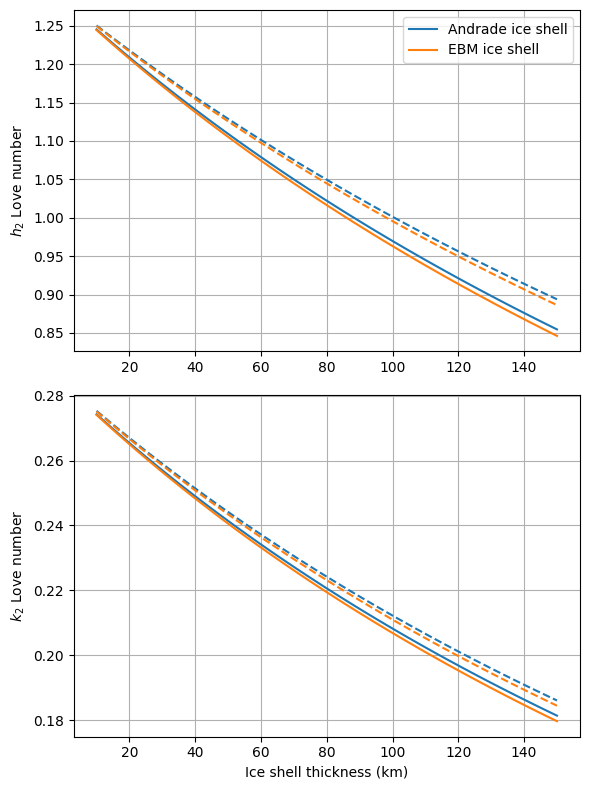

In [19]:
fig, ax = plt.subplots( 2,1, figsize=(6,8) )

l1, = ax[0].plot(d_ice/1000, np.real(h_ad), linestyle='-', label='Andrade ice shell' )
l2, = ax[0].plot(d_ice/1000, np.real(h_eb), linestyle='-', label='EBM ice shell' )
ax[0].plot(d_ice/1000, np.real(hc_ad), linestyle='--', color=l1.get_color() )
ax[0].plot(d_ice/1000, np.real(hc_eb), linestyle='--',  color=l2.get_color() )

ax[0].grid()
ax[0].set_ylabel('$h_2$ Love number')
ax[0].legend()

l1, = ax[1].plot(d_ice/1000, np.real(k_ad), linestyle='-' )
l2, = ax[1].plot(d_ice/1000, np.real(k_eb), linestyle='-' )
ax[1].plot(d_ice/1000, np.real(kc_ad), linestyle='--', color=l1.get_color() )
ax[1].plot(d_ice/1000, np.real(kc_eb), linestyle='--',  color=l2.get_color() )

ax[1].grid()
ax[1].set_ylabel('$k_2$ Love number')
ax[1].set_xlabel('Ice shell thickness (km)')

plt.tight_layout()


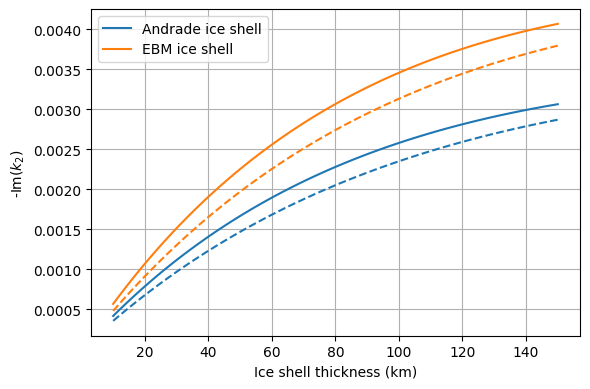

In [20]:
plt.figure( figsize=(6,4) )

l1, = plt.plot(d_ice/1000, -np.imag(k_ad), linestyle='-', label='Andrade ice shell' )
l2, = plt.plot(d_ice/1000, -np.imag(k_eb), linestyle='-', label='EBM ice shell' )

plt.plot(d_ice/1000, -np.imag(kc_ad), linestyle='--', color=l1.get_color() )
plt.plot(d_ice/1000, -np.imag(kc_eb), linestyle='--', color=l2.get_color() )


plt.grid()
plt.xlabel('Ice shell thickness (km)')
plt.ylabel('-Im($k_2$)')
plt.legend()

plt.tight_layout()
